# Stage 1 — Human Baseline: Reliability & Gender Signal

**Project:** recruitview-gender-bias  
**Dataset:** RecruitView (2,011 responses · 331 participants · 12 z-scored targets)

This notebook tells the Stage 1 story in five parts:

| Part | What it covers |
|---|---|
| **1 — Dataset overview** | Who is in the sample: participants, responses, questions, duration |
| **2 — Score distributions** | How the 12 targets are distributed and how they differ by gender |
| **3 — Variable inventory** | Which targets are text-recoverable vs modality-dependent → scopes the LLM comparison |
| **4 — Variance decomposition** | How much of each score is stable person signal vs noise (G-theory, Bayesian mixed models) |
| **5 — Gender effects** | Model-based gender fixed effect — the human baseline for Stage 2+ |

**The central question Stage 1 answers:**  
*Are human-derived RecruitView ratings reliable enough to serve as a person-level criterion — or should they be treated as one fallible measurement method among several?*

**Gender encoding:** `0 = female`, `1 = male`.

> Parts 4–5 load pre-computed outputs from `outputs/stage1/` (59 Bayesian fits run in `src/stage1_fit.py`).  
> Parts 1–3 are computed live from `data/recruitview_full.csv` (gated, CC BY-NC 4.0; regenerate via `src/prepare_full_dataset.py`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import seaborn as sns
from scipy import stats
from IPython.display import Image, display as ipy_display

# ── Neural Haze palette ──────────────────────────────────────────────────────
NH = dict(
    acidLime       = "#C8F135",
    limeMid        = "#A3D420",
    electricViolet = "#9B30FF",
    neuralCyan     = "#00F5D4",
    hotMagenta     = "#FF2D78",
    ghostWhite     = "#F0EFF8",
    mist           = "#C5C3D6",
    slate          = "#6E6A88",
    deepSpace      = "#1C1928",
    void           = "#0B0A14",
)

# Gender colours: female = hotMagenta (#FF2D78), male = electricViolet (#9B30FF)
G_COLOR = {0: NH["hotMagenta"], 1: NH["electricViolet"]}
G_LABEL = {0: "Female", 1: "Male"}
PALETTE  = [G_COLOR[0], G_COLOR[1]]

# Global matplotlib style (Neural Haze dark theme)
plt.rcParams.update({
    "figure.facecolor":  NH["void"],
    "savefig.facecolor": NH["void"],
    "axes.facecolor":    NH["deepSpace"],
    "axes.edgecolor":    NH["slate"],
    "axes.labelcolor":   NH["ghostWhite"],
    "axes.titlecolor":   NH["ghostWhite"],
    "xtick.color":       NH["mist"],
    "ytick.color":       NH["mist"],
    "text.color":        NH["ghostWhite"],
    "grid.color":        NH["slate"],
    "grid.alpha":        0.35,
    "figure.dpi":        130,
    "savefig.dpi":       150,
    "savefig.bbox":      "tight",
})

# ── Paths ────────────────────────────────────────────────────────────────────
ROOT = Path.cwd()
while not (ROOT / "outputs" / "stage1").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

OUT_DIR = ROOT / "outputs" / "stage1"
HAS_RAW = (ROOT / "data" / "recruitview_full.csv").exists()

BIG_FIVE    = ["openness", "conscientiousness", "extraversion",
               "agreeableness", "neuroticism", "overall_personality"]
PERFORMANCE = ["interview_score", "answer_score", "speaking_skills",
               "confidence_score", "facial_expression", "overall_performance"]
TARGETS     = BIG_FIVE + PERFORMANCE

print(f"Repo root  : {ROOT}")
print(f"Raw scores : {'✓  data/recruitview_full.csv' if HAS_RAW else '✗  not found — Parts 1–3 skipped'}")
print(f"Stage1 out : {OUT_DIR}")

Repo root  : /Users/Olga/Documents/interview_hr
Raw scores : ✓  data/recruitview_full.csv
Stage1 out : /Users/Olga/Documents/interview_hr/outputs/stage1


## Part 1 — Dataset overview

How many participants, responses, and questions are in the sample, and how is the sample split by gender?

In [2]:
if HAS_RAW:
    df = pd.read_csv(ROOT / "data" / "recruitview_full.csv")
    df["gender_label"] = df["gender"].map(G_LABEL)

    resp = df["gender"].value_counts().sort_index()
    part = df.groupby("user_no")["gender"].first().value_counts().sort_index()

    summary = pd.DataFrame({
        "Participants": part.rename(index=G_LABEL),
        "Responses":    resp.rename(index=G_LABEL),
    })
    summary.loc["Total"] = summary.sum()
    display(summary)

    print(f"\nUnique questions : {df['question_id'].nunique()}")
    print(f"Question sets    : 15 (reconstructed from co-occurrence)")
    print(f"Responses/person : median {df.groupby('user_no').size().median():.0f}  "
          f"(range {df.groupby('user_no').size().min()}–{df.groupby('user_no').size().max()})")
else:
    df = None
    print("data/recruitview_full.csv not found — skipping Parts 1–3.")

,Participants,Responses
gender,,
Female,79,498
Male,252,1513
Total,331,2011



Unique questions : 76
Question sets    : 15 (reconstructed from co-occurrence)
Responses/person : median 6  (range 1–17)


### Sample composition by gender

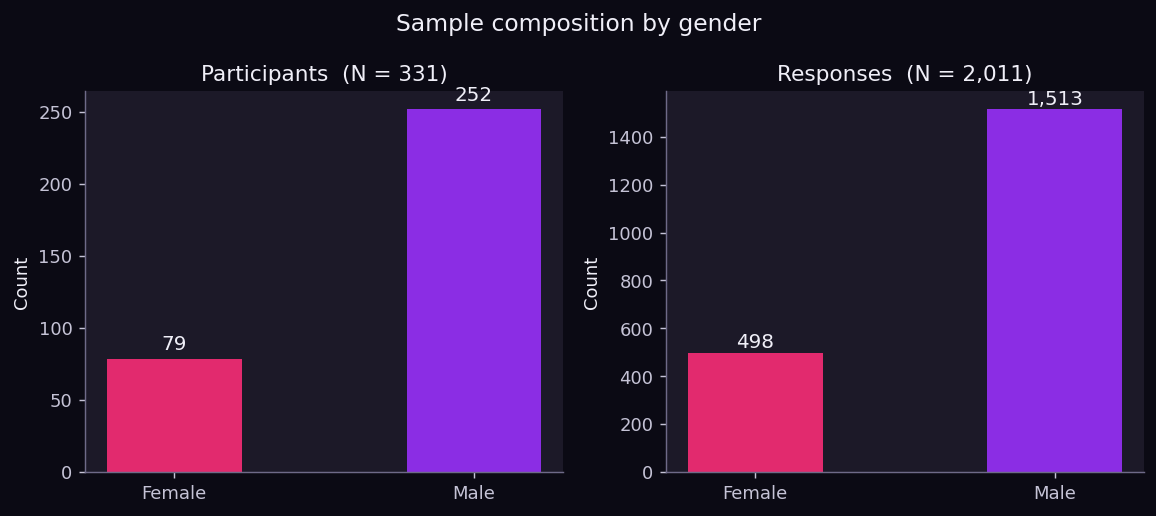

In [3]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, (counts, title) in zip(axes, [
        (part, f"Participants  (N = {part.sum()})"),
        (resp,  f"Responses  (N = {resp.sum():,})"),
    ]):
        labels = [G_LABEL[i] for i in counts.index]
        colors = [G_COLOR[i]  for i in counts.index]
        bars = ax.bar(labels, counts.values, color=colors, width=0.45, alpha=0.88)
        for b, v in zip(bars, counts.values):
            ax.text(b.get_x() + b.get_width() / 2, v + 3, f"{v:,}",
                    ha="center", va="bottom", fontsize=11)
        ax.set_title(title)
        ax.set_ylabel("Count")
        ax.spines[["top", "right"]].set_visible(False)

    fig.suptitle("Sample composition by gender", fontsize=13)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "01_gender_distribution.png")
    plt.show()

### Answer duration by gender

`duration` is a categorical metadata variable ({short, medium, long}). It is **strongly associated with all 12 targets** (η² = .03–.12, all p < 1e-13) and carries genuine person/trait signal (see Part 4), so it enters the models as a covariate — not as pure noise to be removed.

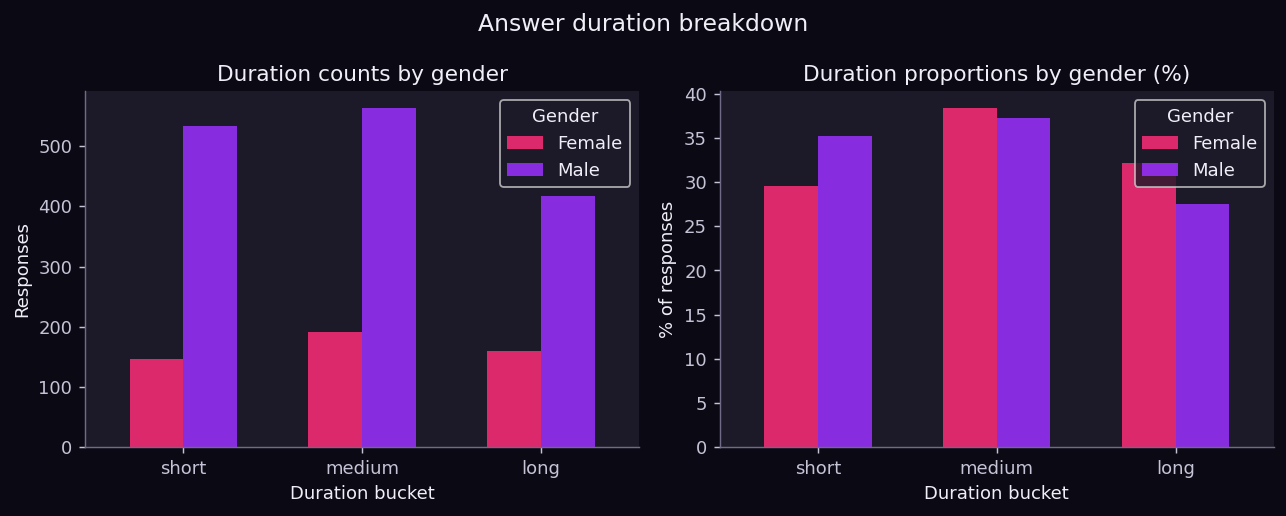

duration,short,medium,long
Gender,,,
Female,29.5,38.4,32.1
Male,35.2,37.2,27.6


In [4]:
if df is not None:
    dur = (df.groupby(["gender_label", "duration"]).size()
             .unstack(fill_value=0)
             .reindex(columns=["short", "medium", "long"]))
    dur_pct = dur.div(dur.sum(axis=1), axis=0) * 100

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # counts
    dur.T.plot(kind="bar", ax=axes[0], color=PALETTE, alpha=0.85, width=0.6)
    axes[0].set_title("Duration counts by gender")
    axes[0].set_xlabel("Duration bucket")
    axes[0].set_ylabel("Responses")
    axes[0].tick_params(axis="x", rotation=0)
    axes[0].legend(title="Gender", labels=["Female", "Male"])
    axes[0].spines[["top", "right"]].set_visible(False)

    # proportions
    dur_pct.T.plot(kind="bar", ax=axes[1], color=PALETTE, alpha=0.85, width=0.6)
    axes[1].set_title("Duration proportions by gender (%)")
    axes[1].set_xlabel("Duration bucket")
    axes[1].set_ylabel("% of responses")
    axes[1].tick_params(axis="x", rotation=0)
    axes[1].legend(title="Gender", labels=["Female", "Male"])
    axes[1].spines[["top", "right"]].set_visible(False)

    fig.suptitle("Answer duration breakdown", fontsize=13)
    fig.tight_layout()
    plt.show()

    display(dur_pct.round(1).rename_axis("Gender"))

## Part 2 — Score distributions by gender

Violin plots for all 12 targets split by gender (y-axis clipped to ±4 SD; the data contain extreme outliers up to |z| ≈ 10 that are kept). Title colour marks the block: **cyan = personality**, **lime = performance**.

### Violin plots — all 12 targets

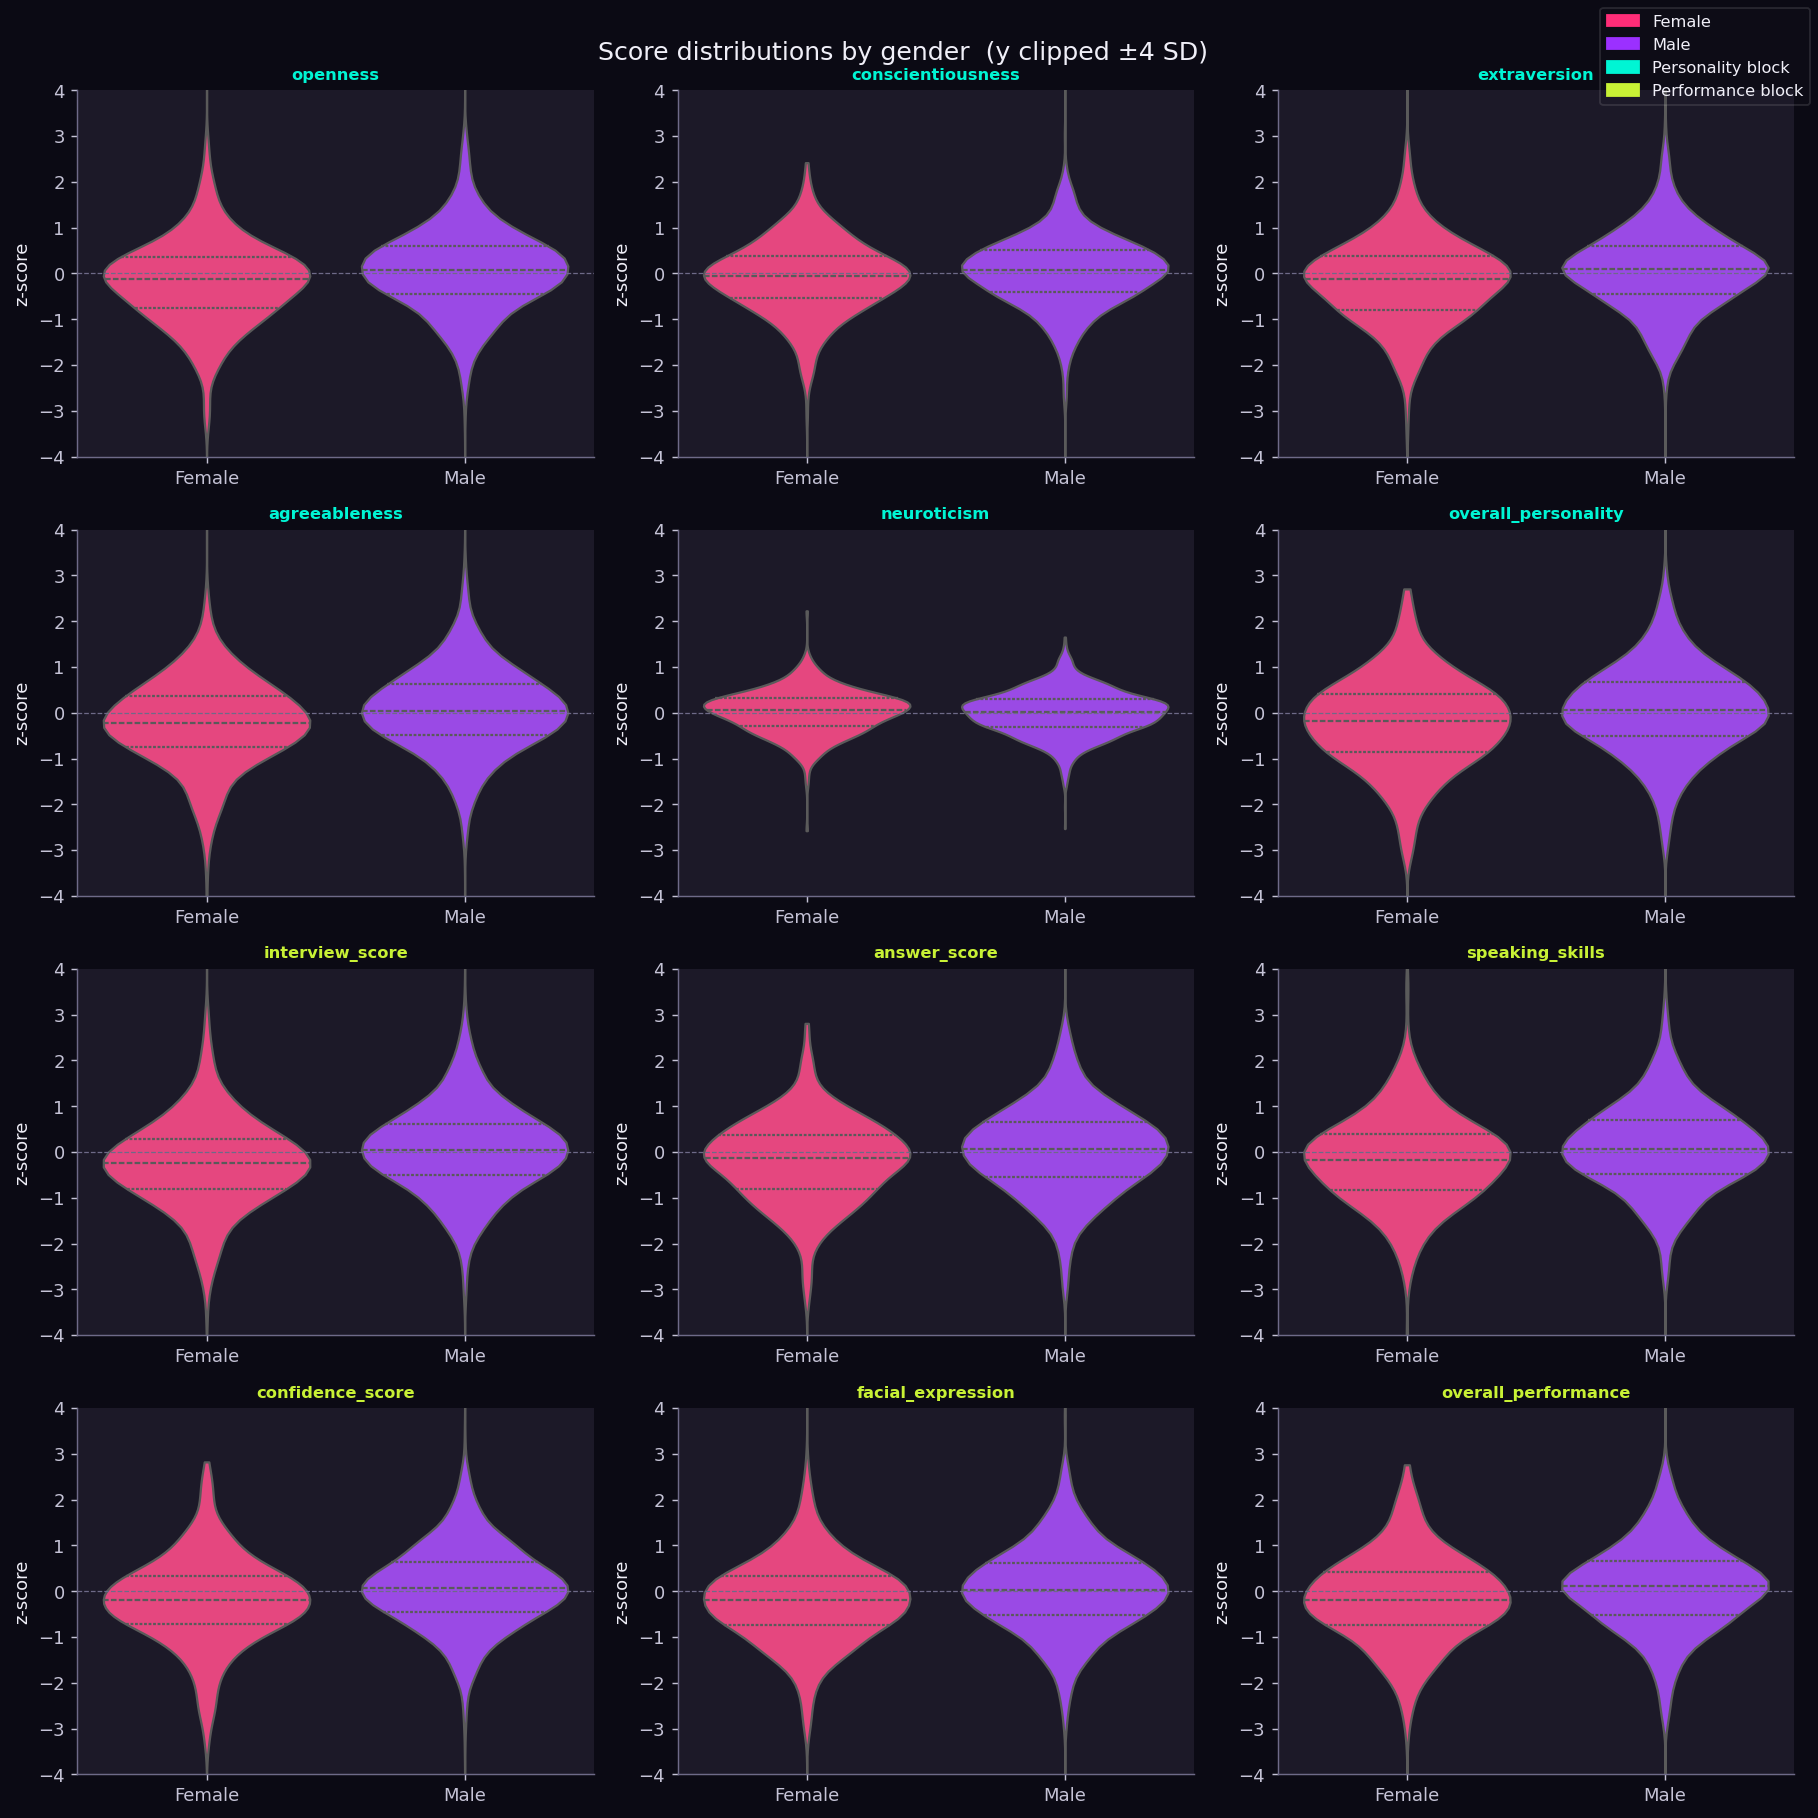

In [5]:
if df is not None:
    fig, axes = plt.subplots(4, 3, figsize=(14, 14))
    for ax, col in zip(axes.ravel(), TARGETS):
        title_color = NH["neuralCyan"] if col in BIG_FIVE else NH["acidLime"]
        sns.violinplot(
            data=df, x="gender_label", y=col, hue="gender_label",
            order=["Female", "Male"], palette=PALETTE,
            inner="quartile", cut=0, legend=False, ax=ax,
        )
        ax.set_ylim(-4, 4)
        ax.set_title(col, color=title_color, fontweight="bold", fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("z-score")
        ax.axhline(0, color=NH["slate"], lw=0.7, ls="--")
        ax.spines[["top", "right"]].set_visible(False)

    legend_patches = [
        mpatches.Patch(color=NH["hotMagenta"],     label="Female"),
        mpatches.Patch(color=NH["electricViolet"], label="Male"),
        mpatches.Patch(color=NH["neuralCyan"],     label="Personality block"),
        mpatches.Patch(color=NH["acidLime"],       label="Performance block"),
    ]
    fig.legend(handles=legend_patches, loc="upper right", framealpha=0.15, fontsize=9)
    fig.suptitle("Score distributions by gender  (y clipped ±4 SD)", fontsize=14)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "02_distributions_by_gender.png")
    plt.show()

### Descriptive effect sizes (Cohen's d)

Response-level Cohen's d (male relative to female). Positive = men score higher. These are raw, response-level estimates without accounting for the repeated-measures structure; the model-based gender fixed effect (Part 5) is the authoritative estimate.

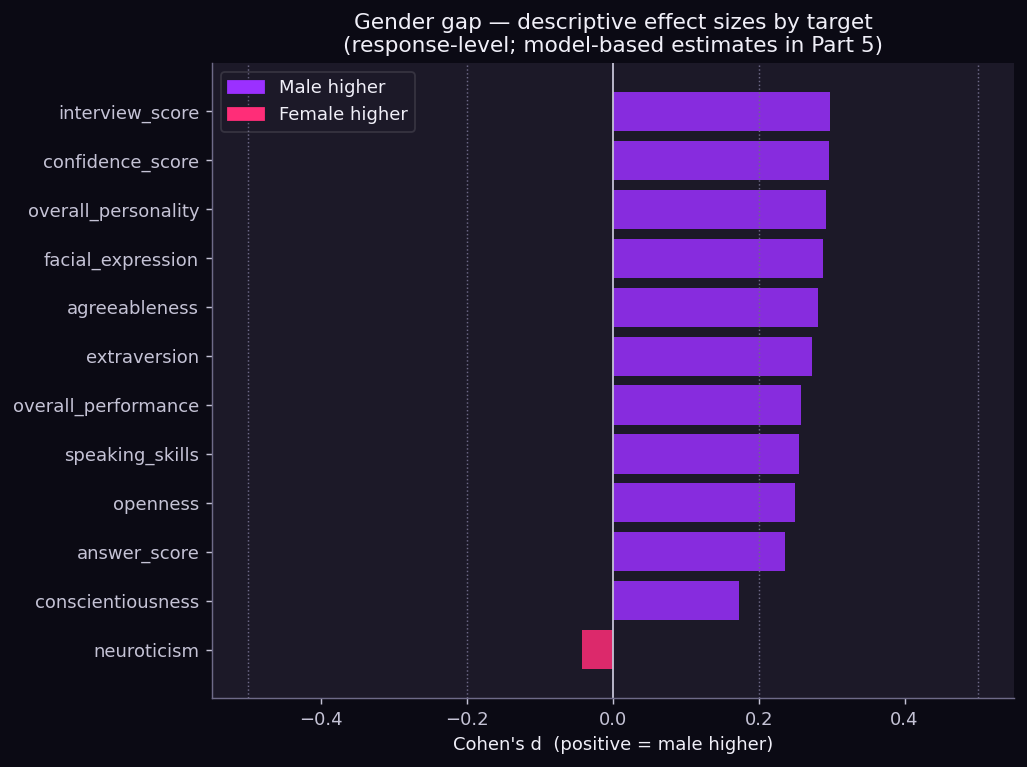

In [6]:
def cohens_d(a, b):
    a, b = a.dropna(), b.dropna()
    pooled = np.sqrt(
        ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    )
    return (a.mean() - b.mean()) / pooled if pooled else np.nan

if df is not None:
    fem, mal = df[df.gender == 0], df[df.gender == 1]
    d_vals = pd.Series(
        {col: cohens_d(mal[col], fem[col]) for col in TARGETS}
    ).sort_values()

    colors = [NH["electricViolet"] if v >= 0 else NH["hotMagenta"] for v in d_vals]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(d_vals.index, d_vals.values, color=colors, alpha=0.85)
    for thr in (0.2, 0.5, -0.2, -0.5):
        ax.axvline(thr, color=NH["slate"], ls=":", lw=0.8)
    ax.axvline(0, color=NH["mist"], lw=1)
    ax.set_xlabel("Cohen's d  (positive = male higher)")
    ax.set_title("Gender gap — descriptive effect sizes by target\n"
                 "(response-level; model-based estimates in Part 5)")
    ax.spines[["top", "right"]].set_visible(False)

    legend_patches = [
        mpatches.Patch(color=NH["electricViolet"], label="Male higher"),
        mpatches.Patch(color=NH["hotMagenta"],     label="Female higher"),
    ]
    ax.legend(handles=legend_patches, framealpha=0.15)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "03_cohens_d_by_target.png")
    plt.show()

## Part 3 — Variable inventory: modality triage for the LLM comparison

Human ratings were produced from **video** (visual + vocal + verbal). Stage 2+ scores the same responses from **transcripts only**. This creates a multi-trait multi-method (MTMM) structure: human and LLM ratings are two fallible measurement *channels*, not truth vs. test.

A construct can be compared across channels only if it is **recoverable from the verbal record**. The table below classifies all 12 targets by text-recoverability and assigns each a role in the LLM comparison phase.

> Targets coloured **red / Exclude** will not be submitted to the LLM scorer — any apparent gap there would be a modality artefact, not evidence of bias.

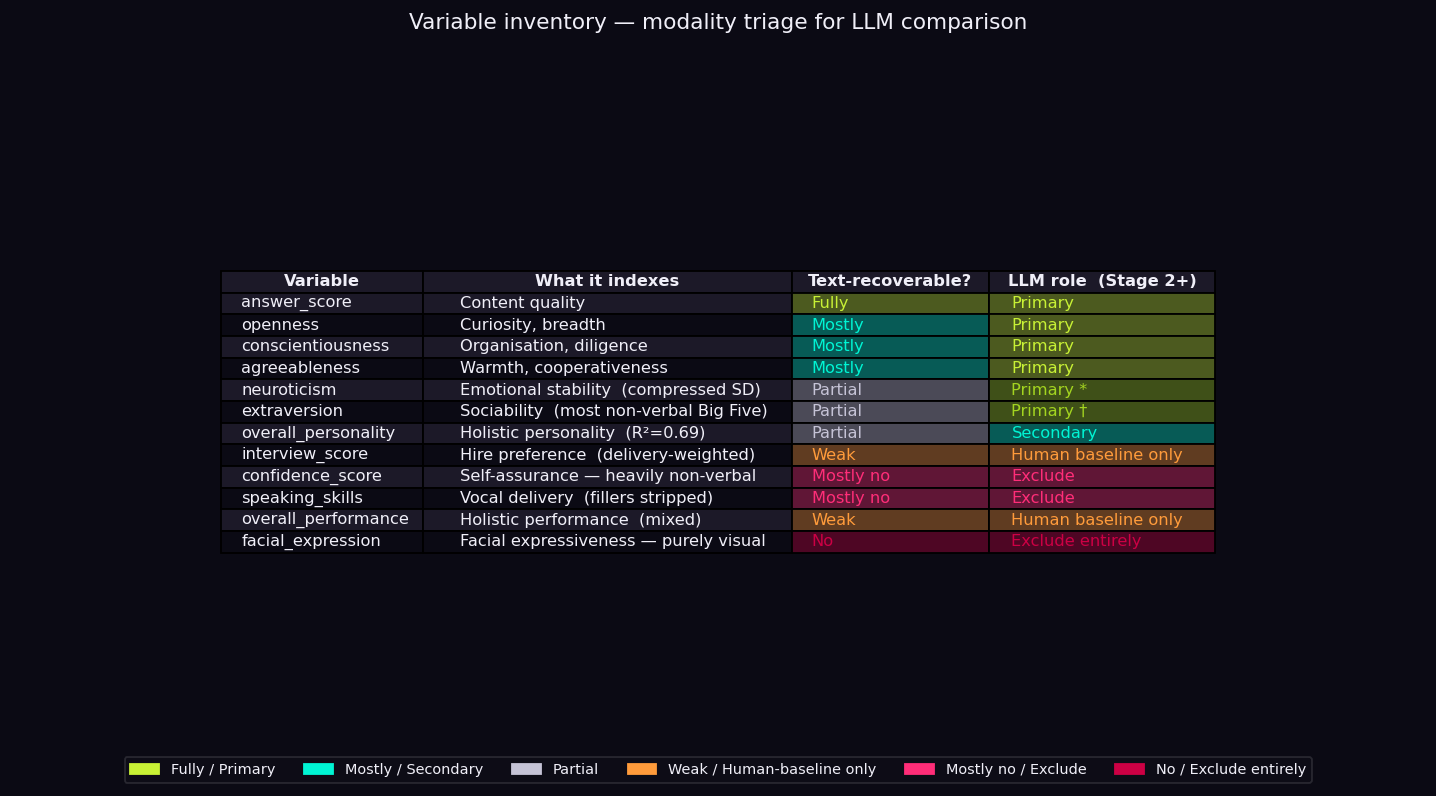

* neuroticism: near-normal distribution, compressed variance — interpret separately
† extraversion: most non-verbally expressed Big Five — flag as modality-sensitive


In [7]:
VAR_INV = [
    # (variable, what it indexes, text-recoverable?, LLM role)
    ("answer_score",       "Content quality",                         "Fully",     "Primary"),
    ("openness",           "Curiosity, breadth",                      "Mostly",    "Primary"),
    ("conscientiousness",  "Organisation, diligence",                 "Mostly",    "Primary"),
    ("agreeableness",      "Warmth, cooperativeness",                 "Mostly",    "Primary"),
    ("neuroticism",        "Emotional stability  (compressed SD)",    "Partial",   "Primary *"),
    ("extraversion",       "Sociability  (most non-verbal Big Five)", "Partial",   "Primary †"),
    ("overall_personality","Holistic personality  (R²=0.69)",         "Partial",   "Secondary"),
    ("interview_score",    "Hire preference  (delivery-weighted)",    "Weak",      "Human baseline only"),
    ("confidence_score",   "Self-assurance — heavily non-verbal",     "Mostly no", "Exclude"),
    ("speaking_skills",    "Vocal delivery  (fillers stripped)",      "Mostly no", "Exclude"),
    ("overall_performance","Holistic performance  (mixed)",           "Weak",      "Human baseline only"),
    ("facial_expression",  "Facial expressiveness — purely visual",   "No",        "Exclude entirely"),
]

RECOV_C = {
    "Fully":     NH["acidLime"],
    "Mostly":    NH["neuralCyan"],
    "Partial":   NH["mist"],
    "Weak":      "#FF9B3B",
    "Mostly no": NH["hotMagenta"],
    "No":        "#CC0044",
}
ROLE_C = {
    "Primary":            NH["acidLime"],
    "Primary *":          NH["limeMid"],
    "Primary †":          NH["limeMid"],
    "Secondary":          NH["neuralCyan"],
    "Human baseline only":"#FF9B3B",
    "Exclude":            NH["hotMagenta"],
    "Exclude entirely":   "#CC0044",
}

headers = ["Variable", "What it indexes", "Text-recoverable?", "LLM role  (Stage 2+)"]

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")
tbl = ax.table(
    cellText=[list(r) for r in VAR_INV],
    colLabels=headers,
    cellLoc="left",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.auto_set_column_width([0, 1, 2, 3])

# header row
for j in range(4):
    c = tbl[0, j]
    c.set_facecolor(NH["deepSpace"])
    c.set_text_props(color=NH["ghostWhite"], fontweight="bold")

# body rows
for i, row in enumerate(VAR_INV, start=1):
    bg = NH["void"] if i % 2 == 0 else NH["deepSpace"]
    for j in range(4):
        tbl[i, j].set_facecolor(bg)
        tbl[i, j].set_text_props(color=NH["ghostWhite"])
    # recoverability cell
    rc = RECOV_C.get(row[2], NH["slate"])
    tbl[i, 2].set_facecolor(to_rgba(rc, 0.35))
    tbl[i, 2].set_text_props(color=rc)
    # role cell
    rl = ROLE_C.get(row[3], NH["slate"])
    tbl[i, 3].set_facecolor(to_rgba(rl, 0.35))
    tbl[i, 3].set_text_props(color=rl)

ax.set_title(
    "Variable inventory — modality triage for LLM comparison",
    color=NH["ghostWhite"], fontsize=12, pad=18,
)

legend_items = [
    mpatches.Patch(color=NH["acidLime"],    label="Fully / Primary"),
    mpatches.Patch(color=NH["neuralCyan"], label="Mostly / Secondary"),
    mpatches.Patch(color=NH["mist"],       label="Partial"),
    mpatches.Patch(color="#FF9B3B",        label="Weak / Human-baseline only"),
    mpatches.Patch(color=NH["hotMagenta"], label="Mostly no / Exclude"),
    mpatches.Patch(color="#CC0044",        label="No / Exclude entirely"),
]
ax.legend(handles=legend_items, loc="lower center", ncol=6,
          framealpha=0.15, bbox_to_anchor=(0.5, -0.04),
          labelcolor=NH["ghostWhite"], fontsize=8)

fig.savefig(OUT_DIR / "variable_inventory.png")
plt.show()

print("* neuroticism: near-normal distribution, compressed variance — interpret separately")
print("† extraversion: most non-verbally expressed Big Five — flag as modality-sensitive")

## Part 4 — Variance decomposition & reliability

We reframed Generalizability Theory as a ladder of Bayesian cross-classified mixed-effects models — `(1|user_no) + (1|set_id) + (1|set_id:question_id)` — fitted per target in `src/stage1_fit.py` (59 fits total; all converged r̂ ≤ 1.014). Here we load the pre-computed outputs.

> **Key constraint:** only the derived scores are available — no raw pairwise data, no rater identifiers. With one observation per person×question cell, the person×question interaction is **confounded with the residual**. VPC_person is therefore a **lower bound** on signal; the residual is an **upper bound** on noise. Inter-rater reliability is not estimable at this stage.

In [8]:
tc = pd.read_csv(OUT_DIR / "target_classification.csv")
vc = pd.read_csv(OUT_DIR / "variance_components.csv")
ge = pd.read_csv(OUT_DIR / "gender_effects.csv")
print(f"Loaded: target_classification {tc.shape}  |  "
      f"variance_components {vc.shape}  |  gender_effects {ge.shape}")

Loaded: target_classification (12, 25)  |  variance_components (210, 27)  |  gender_effects (24, 6)


### Where the variance goes

Variance splits almost entirely between **person** (~18–30%) and **residual** (~70–82%); set and question components are negligible. Question variance is near-zero by construction: the source labels came from *within-question* pairwise comparisons, so between-question means are already netted out.

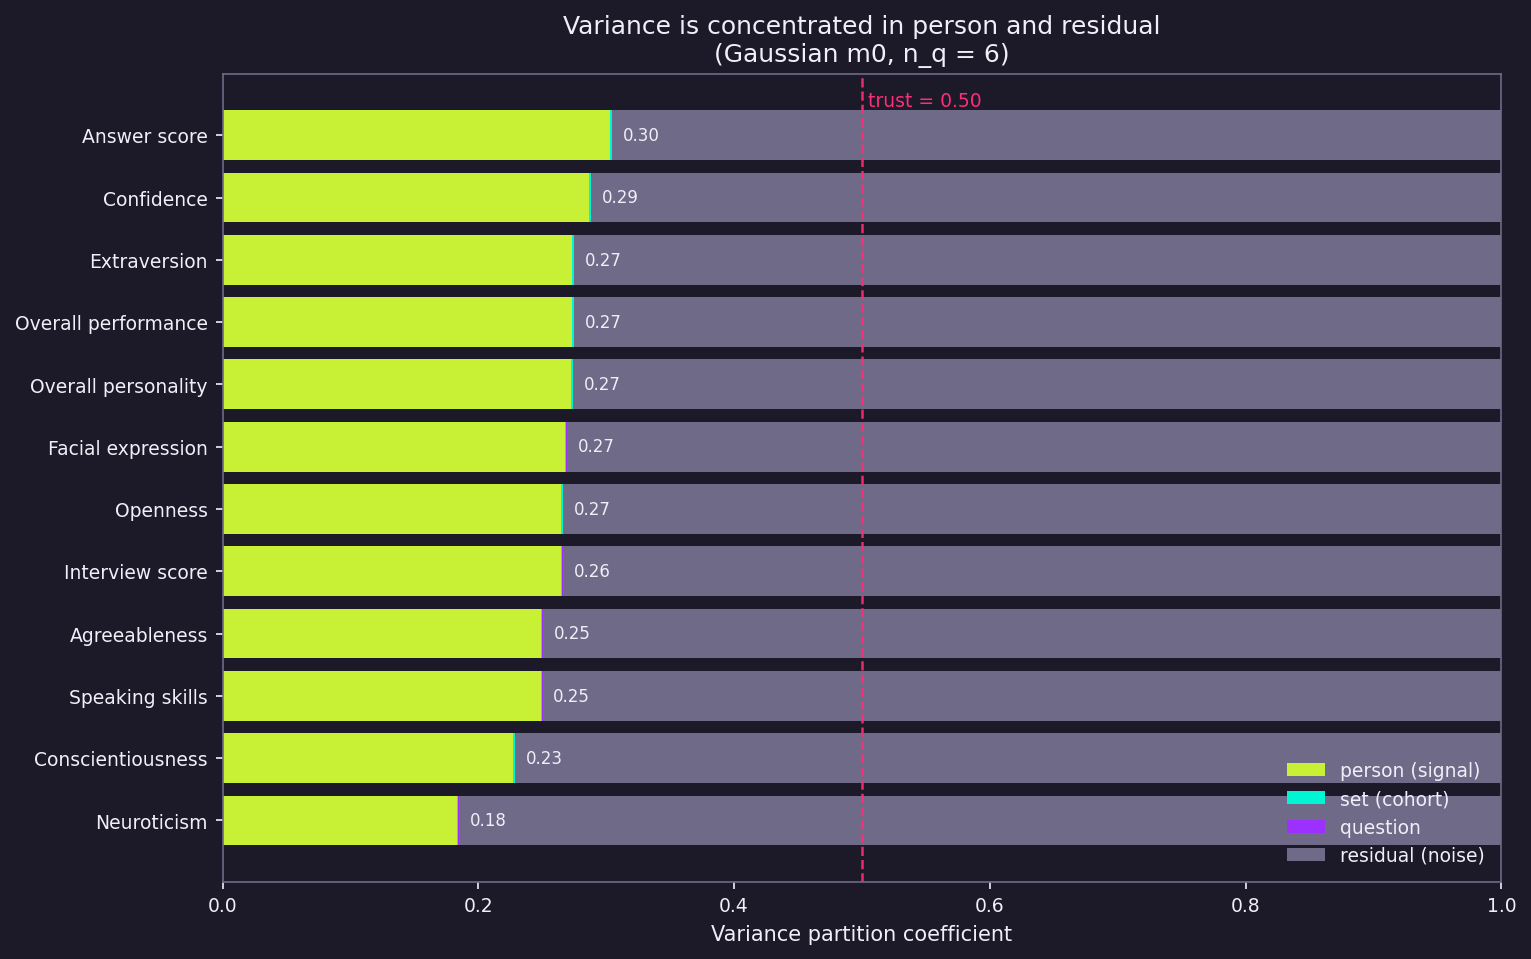

In [9]:
ipy_display(Image(str(OUT_DIR / "vpc_stacked_bars.png"), width=750))

### Reliability and trust classification

**No target reaches "trust"** (VPC_person ≥ .50, Eρ² ≥ .70). Eleven of twelve are **do-not-trust**; only `answer_score` is **marginal** (VPC_person = .303, Eρ² = .722). Single-clip person consistency ranges from .18 to .30; the six-question person-aggregate reliability ranges from .57 to .72 — moderate, but short of conventional thresholds for most targets.

The verdict is **robust to tail treatment**: even the most optimistic (scale-based Student-t) upper bound on VPC_person never crosses .50.

,target,block,VPC_person,Erho2,Phi,robust_range_lo,robust_range_hi,class
0,answer_score,performance,0.303,0.722,0.722,0.238,0.492,marginal
1,confidence_score,performance,0.287,0.706,0.706,0.224,0.473,do-not-trust
2,extraversion,personality,0.274,0.692,0.692,0.224,0.478,do-not-trust
3,overall_performance,performance,0.273,0.692,0.692,0.215,0.485,do-not-trust
4,overall_personality,personality,0.273,0.691,0.691,0.212,0.474,do-not-trust
5,facial_expression,performance,0.267,0.686,0.685,0.215,0.445,do-not-trust
6,openness,personality,0.265,0.683,0.682,0.175,0.441,do-not-trust
7,interview_score,performance,0.265,0.682,0.682,0.176,0.468,do-not-trust
8,agreeableness,personality,0.249,0.664,0.664,0.164,0.466,do-not-trust
9,speaking_skills,performance,0.249,0.664,0.664,0.141,0.456,do-not-trust


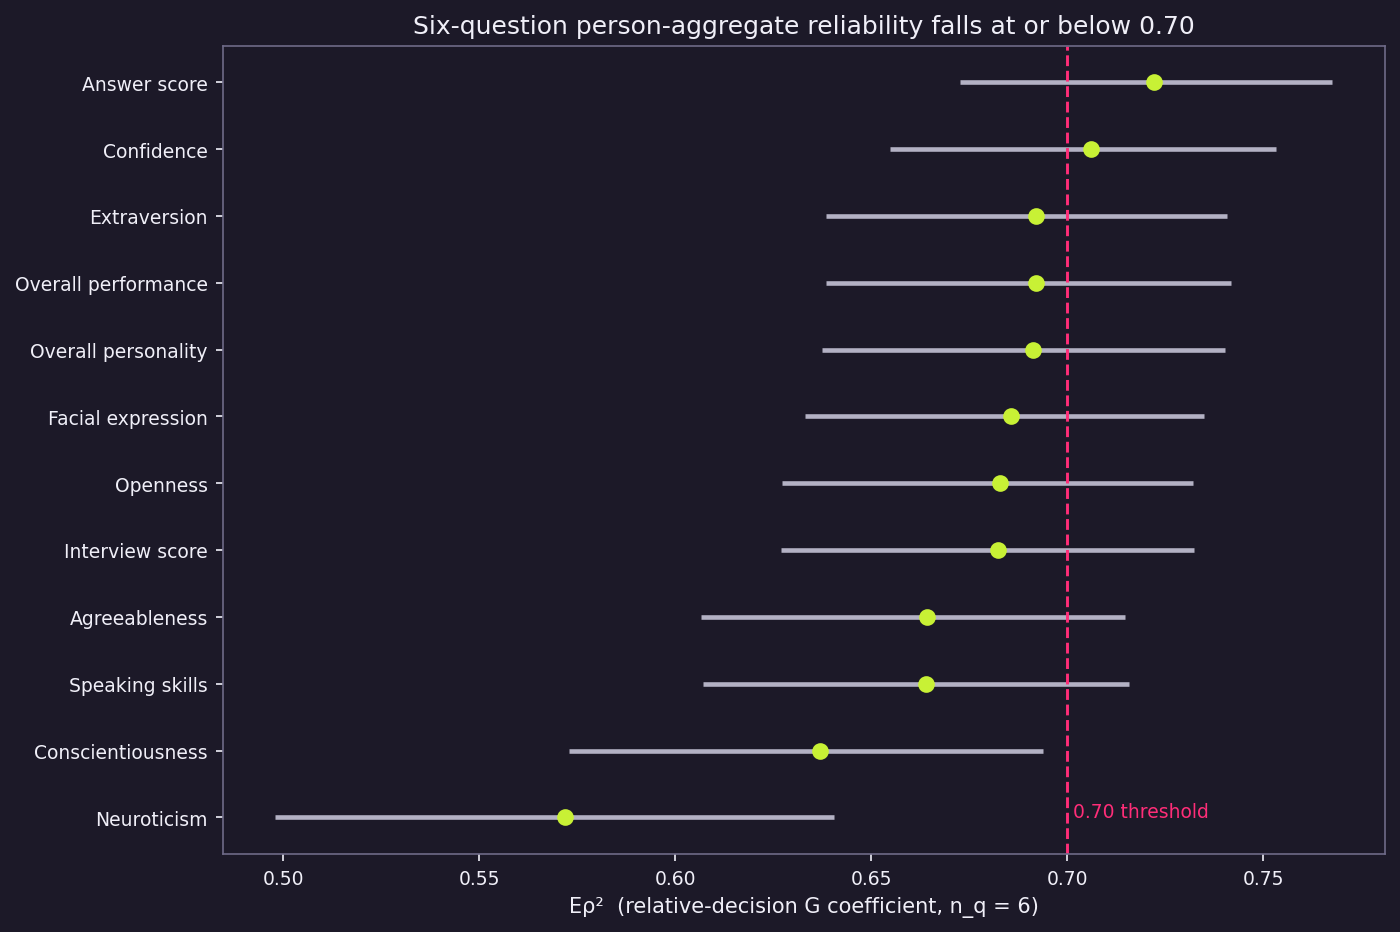

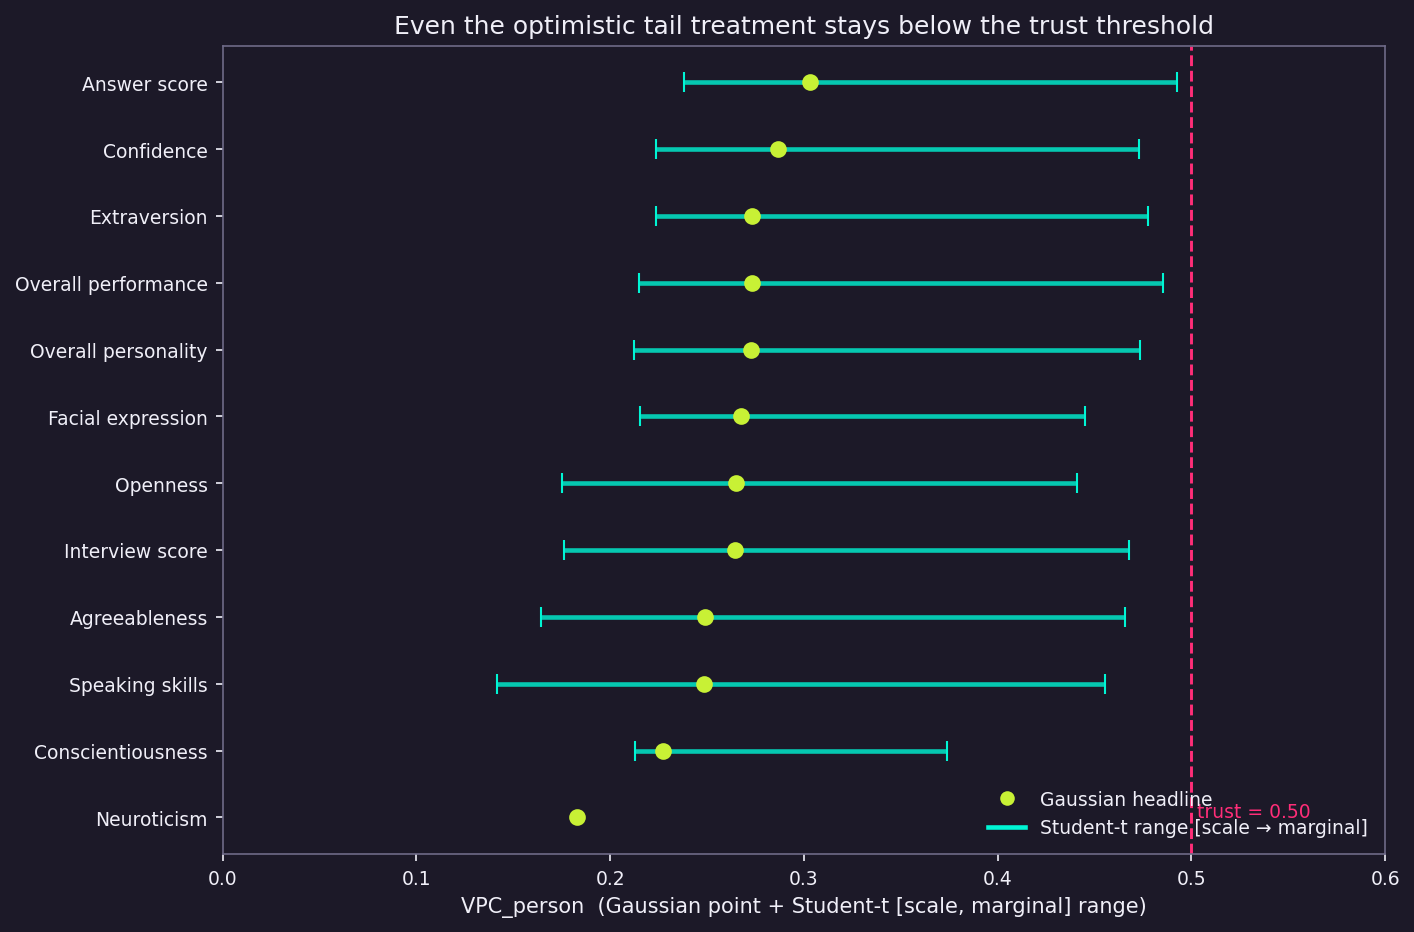

In [10]:
cols = ["target", "block", "VPC_person", "Erho2", "Phi",
        "robust_range_lo", "robust_range_hi", "class"]
tc_disp = (tc[[c for c in cols if c in tc.columns]]
           .sort_values("VPC_person", ascending=False)
           .round(3)
           .reset_index(drop=True))
display(tc_disp)

ipy_display(Image(str(OUT_DIR / "erho2_forest.png"), width=750))
ipy_display(Image(str(OUT_DIR / "vpc_person_robust_range.png"), width=750))

### Answer duration carries genuine person signal

Partialling out duration (model m1d) dropped VPC_person by .05–.094 across the heavy-tailed targets, and the drop came almost entirely from the **person** component — not the residual. Verbose participants are consistently scored higher, so answer length is partly a stable trait expression. This cautions against treating duration as pure noise to be removed; it is modelled as a covariate *and* tested as a facilitator of trait expression.

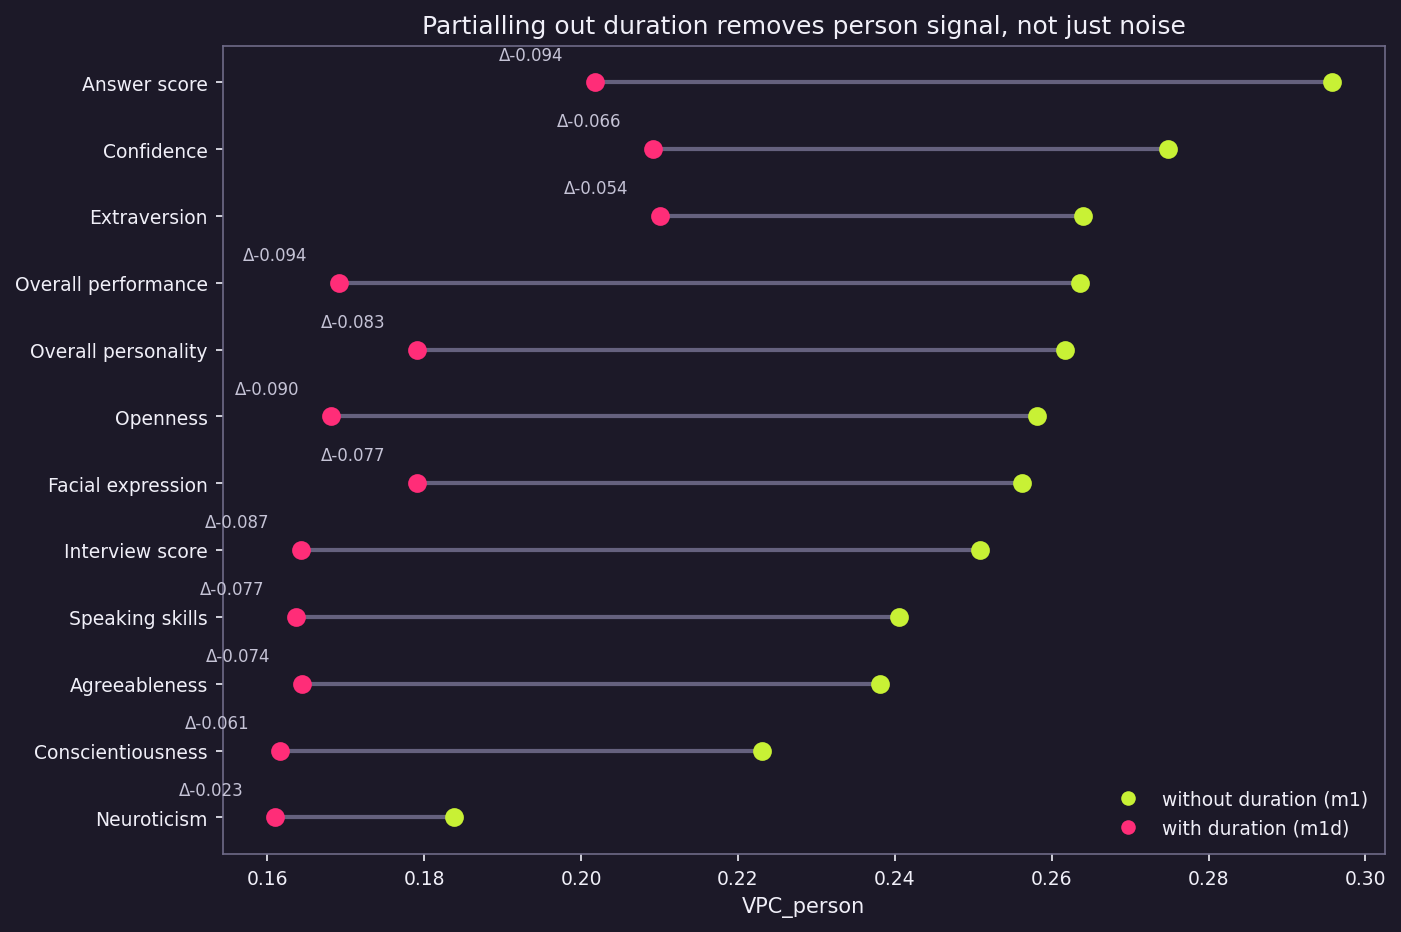

In [11]:
ipy_display(Image(str(OUT_DIR / "duration_slope.png"), width=750))

## Part 5 — Gender effects: the human baseline

Holding the design constant (crossed REs + set/question structure), the model-based gender fixed effect from model m1 (male relative to female) is the clean human-baseline gender signal that Stage 2+ will benchmark the LLM against.

Credible intervals that exclude zero mean the effect is reliably positive (male higher) after accounting for all design factors. The m1d column shows the same effect after additionally controlling for answer duration — a test of whether the gap is explained by men speaking longer.

,target,gender_coef,ci_lo,ci_hi,m1d_coef
0,interview_score,0.393,0.207,0.578,0.341
1,overall_personality,0.381,0.195,0.570,0.335
2,agreeableness,0.364,0.179,0.549,0.322
3,facial_expression,0.362,0.185,0.539,0.318
4,speaking_skills,0.344,0.152,0.540,0.292
5,confidence_score,0.340,0.173,0.512,0.302
6,overall_performance,0.335,0.145,0.526,0.287
7,extraversion,0.315,0.143,0.483,0.279
8,openness,0.306,0.129,0.486,0.257
9,answer_score,0.305,0.112,0.493,0.264


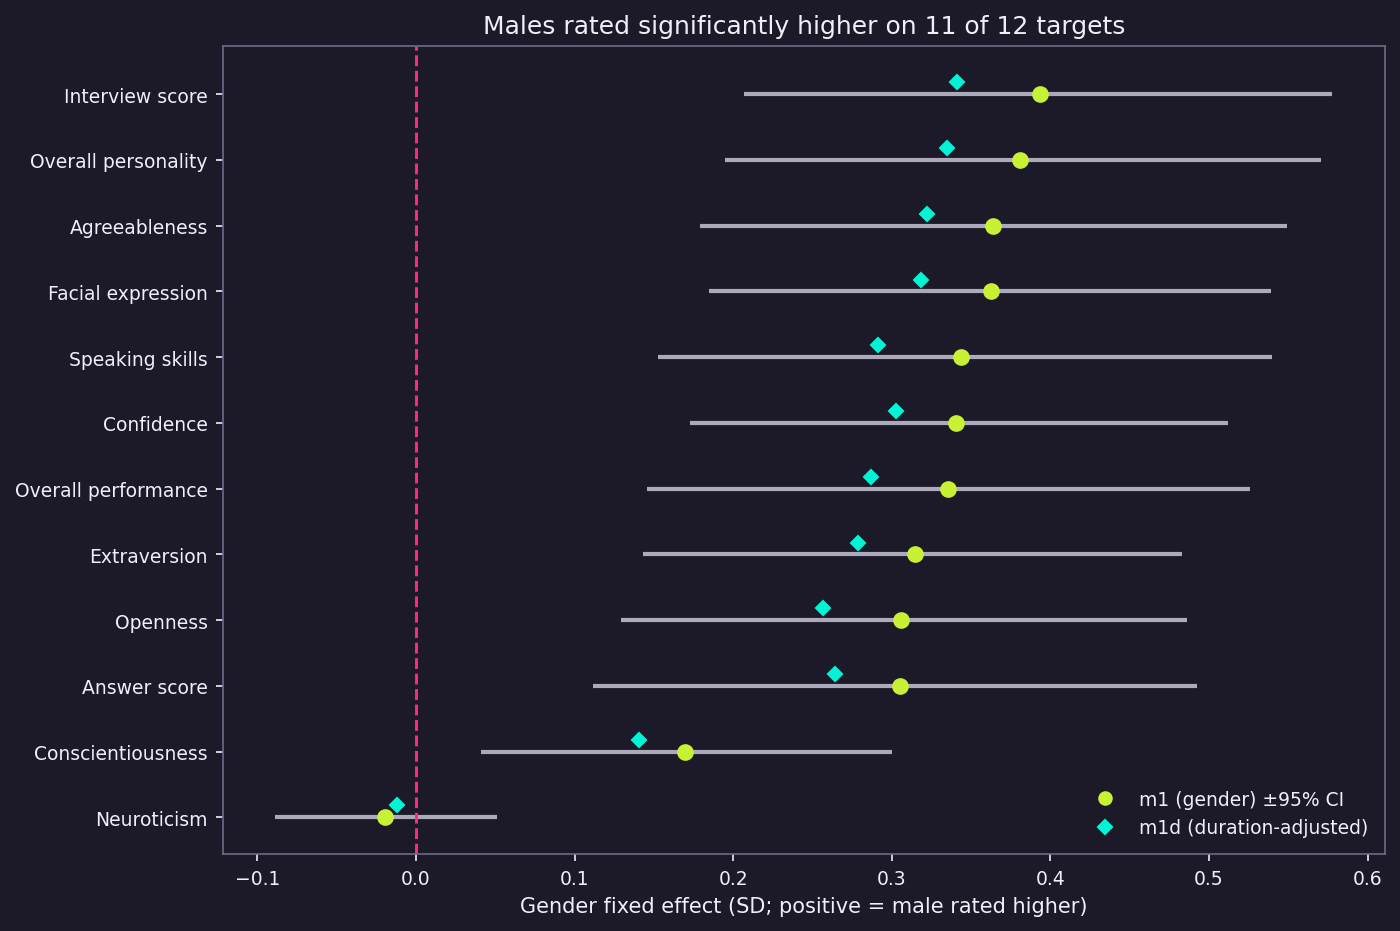

In [12]:
ge_m1  = ge[ge["model"] == "m1"][["target", "gender_coef", "ci_lo", "ci_hi"]].copy()
ge_m1d = ge[ge["model"] == "m1d"][["target", "gender_coef"]].rename(
    columns={"gender_coef": "m1d_coef"}
)
gender_table = (ge_m1.merge(ge_m1d, on="target")
                .sort_values("gender_coef", ascending=False)
                .round(3)
                .reset_index(drop=True))
display(gender_table)

ipy_display(Image(str(OUT_DIR / "gender_forest.png"), width=750))

### What the gender pattern tells us

The ratings assign higher scores to men on **11 of 12 targets** (0.17–0.39 SD; credible intervals exclude zero). Only **neuroticism** is null (−0.020, CI [−0.089, 0.051]).

**Comparison with self-report Big Five norms.** The well-established sex differences in self-report show women scoring *higher* on Neuroticism (d ≈ −0.40, the most robust effect) and Agreeableness (d ≈ −0.15 to −0.50) — a pattern that replicates across 55 nations (Schmitt et al., 2008) and persists, attenuated, in Indian samples (Gaikwad, 2021; Magan et al., 2014). Our observer-based ratings agree only on the weak, culturally variable traits (men slightly higher on Conscientiousness and Openness) but **diverge** on the two robust female-higher effects:

- **Agreeableness is reversed** — men rated higher, the opposite of global self-report
- **Neuroticism is null** — where self-report predicts the largest female-higher gap

A uniform male-higher pattern including an Agreeableness reversal and a Neuroticism null does not correspond to any documented Big Five personality profile. This is most consistent with the ratings indexing *perceived interview performance* and a general evaluative impression rather than latent trait standing.

**Duration mediation is partial.** Controlling for answer length (m1d) attenuates the effects by ~12–16% but leaves 11/12 significant — about 85% of the gap is independent of how long candidates spoke.

**Limits of inference.** Because rater identifiers are unavailable, this divergence cannot be attributed to rater bias versus genuine group differences. It is carried forward as a **measurement property of the human-derived scores**, not as established bias — and it is exactly what the LLM comparison in Stage 2+ will be benchmarked against.

## Summary

| Finding | Result |
|---|---|
| Person signal per clip (VPC_person) | 0.18 – 0.30 across all 12 targets |
| Six-question person-aggregate reliability (Eρ²) | 0.57 – 0.72 — borderline for most |
| Targets reaching "trust" (VPC_person ≥ .50) | **0 of 12** |
| Best target | `answer_score` — **marginal** (Eρ² = 0.72) |
| Verdict robust to tail treatment? | Yes — upper bound never crosses 0.50 |
| Gender gap | Ratings score men higher on **11/12** targets (0.17–0.39 SD) |
| Neuroticism | Null — and this divergence from self-report norms is diagnostic |
| Duration | Carries genuine person signal — not pure noise |

**Decision:** Human ratings are treated **not as ground truth but as one fallible measurement method**, motivating an MTMM comparison against LLM-based scores in Stage 2. The male-higher rating pattern (11/12 targets) — which does not match established Big Five sex differences — is retained as the human baseline against which the LLM will be benchmarked.

**Variable scope for Stage 2+:** Primary targets = `answer_score` + Big Five; Secondary = `overall_personality`; `facial_expression`, `speaking_skills`, `confidence_score`, `interview_score`, `overall_performance` are excluded from LLM outcomes (modality-dependent).

Full write-up: [`docs/stage1_human_baseline.md`](../docs/stage1_human_baseline.md)